# Propose and review candidate objects

**AI4Infra: colored LiDAR -> spatial candidates -> local CLIP suggestions -> your review**

This small-batch prototype uses our cached colored sample and **saved CSF non-ground output**. We have point clouds, not photographs: CLIP receives plain point renders from four angles. Clusters are candidates, and human labels remain separate from model predictions.

Choose **LiDAR Object Review (.venv-ground)**, or `.venv-ground/Scripts/python.exe`, as the kernel. Packages and public CLIP weights are installed locally. Run from the top the first time. This notebook opens with real figures and model outputs; saving a human review starts **off**.

[inspect_las.ipynb](inspect_las.ipynb) remains our inspection notebook, and [ground_experiments.ipynb](ground_experiments.ipynb) remains our ground-filter notebook. This workflow does not rerun ground filtering or scan the full raw clouds.

The implementation is accessible in [object_candidates.py](object_candidates.py), [object_views.py](object_views.py), and [object_clip.py](object_clip.py). New data artifacts live under `outputs/objects/`; model weights live under `.cache-object/models/`.

**Manual labeling is paused. Start with [Candidate quality comparison](#candidate-quality-comparison)** for the completed dense-input pass and saved results. [Short handoff](OBJECT_QUALITY_HANDOFF.md).

**Latest bounded pass: [New candidate comparison](#new-candidate-comparison).** Two new regions, two proposals, saved static views and self-contained browser 3D. [Handoff](NEW_CANDIDATE_HANDOFF.md).

## 1. Set up and choose a manageable region

The inspected laptop has 24 logical CPU threads, about 32 GB RAM, and an RTX 5070 Laptop GPU. This first version uses a **CPU PyTorch build**, without requiring CUDA. CLIP uses at most eight CPU threads. Public weights are downloaded if missing; point clouds and rendered images stay on this computer.

If the kernel starts elsewhere, change `PROJECT_DIR`. Dependencies are recorded in [requirements-object-review.txt](requirements-object-review.txt).

In [1]:
from pathlib import Path
import os, sys
import numpy as np

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "object_candidates.py").is_file():
    raise FileNotFoundError("Set PROJECT_DIR to the folder containing this notebook.")
sys.path.insert(0, str(PROJECT_DIR))
import object_candidates as objects
import object_views as views
import object_clip as clip
import ground_experiment_tools as ground
from ground_experiment_views import show_table, plot_overview
%matplotlib inline
print("Kernel:", sys.executable, "| CPU threads:", os.cpu_count())
HUMAN_REVIEW_PAUSED = True  # Keep review saving paused during candidate-quality assessment.

Kernel: C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\.venv-ground\Scripts\python.exe | CPU threads: 24


Choose one side and an XY rectangle. `REGION_CENTER` uses **absolute source X/Y coordinates**; `REGION_SIZE` gives the widths. The overview uses local coordinates and prints the origin that was subtracted. The starting region is a populated example, not a known missing-road location.

`CONTEXT_MARGIN` adds original colored sample points for human inspection. Clustering uses every saved CSF non-ground point inside the inner rectangle, independently of display sampling. The loader verifies the saved partitions and records zero-based row numbers back to the original development LAS file.

Source cache hit: True | Units: unresolved coordinate units (LAS: US survey foot; sidecar: meter)
Overview XYZ origin: [2453810.1308, 414035.2235, 725.821]


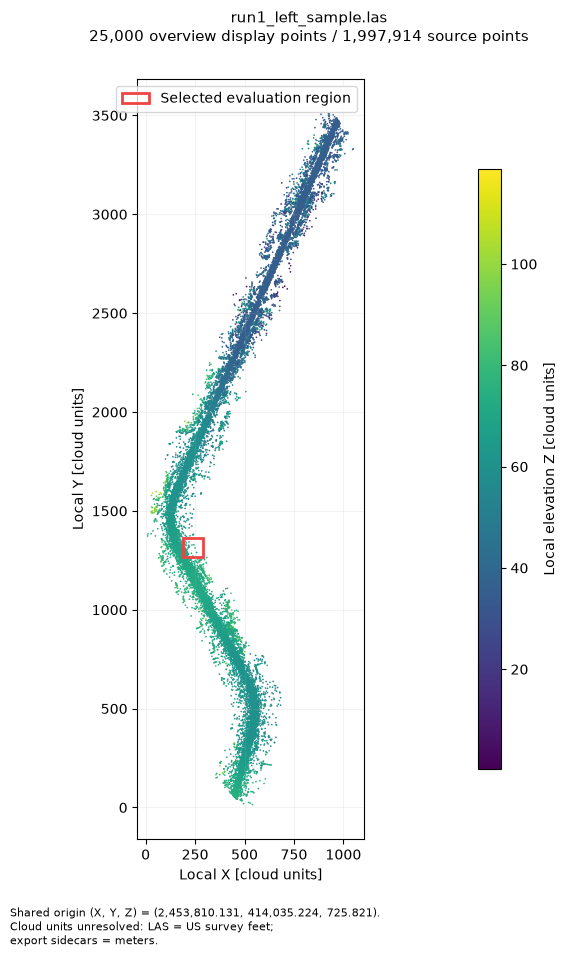

In [2]:
INPUT_SIDE = "left"                  # "left" or "right"; scans stay separate.
CSF_RESULT = "csf_current"           # Or "csf_previous".
REGION_CENTER = (2454050.0, 415350.0) # Absolute source X and Y.
REGION_SIZE = (100.0, 100.0)          # Widths in source coordinate units.
CONTEXT_MARGIN = 8.0
center, half = np.asarray(REGION_CENTER), np.asarray(REGION_SIZE) / 2
roi_xy = [center[0]-half[0], center[0]+half[0], center[1]-half[1], center[1]+half[1]]
source = objects.load_source(PROJECT_DIR, INPUT_SIDE, roi_xy, CONTEXT_MARGIN, CSF_RESULT)
print("Source cache hit:", source["cache_hit"], "| Units:", source["coordinate_units"])
overview = ground.load_overview(source["catalog"], INPUT_SIDE, max_display_points=25_000)
print("Overview XYZ origin:", overview["origin"].tolist())
plot_overview(overview, roi_xy)

## 2. Inspect spacing before selecting clustering distance

LAS headers declare **US survey feet**, while export sidecars declare meters. We report source coordinate units and do not infer physical object sizes. Coordinate scale decodes stored coordinates; it does not resolve this conflict.

The table measures each non-ground point's distance to its nearest other point in 3D, including coincident points if present. Density varies across the scene. A single distance can merge nearby objects or split sparse ones; the suggested scale is only an exploratory heuristic.

In [3]:
spacing = objects.spacing_report(source)
show_table([{"measurement": key, "value": value} for key, value in spacing.items()])

measurement,value
non_ground_processing_points,"4,039"
original_context_points,"23,088"
original_core_points,"11,754"
coordinate_units,unresolved coordinate units (LAS: US survey foot; sidecar: meter)
header_axis_units,"[ ""US survey foot"", ""US survey foot"" ][ ""US survey foot"", ""US survey foot"" ]"
coordinate_scales,"[ 0.0001, 0.0001, 0.0001 ][ 0.0001, 0.0001, 0.0001 ]"
duplicate_xyz_extra_records,0
nearest_neighbor_quantiles,"{ ""p10"": 0.11345845049050855, ""p25"": 0.18229355441369682, ""p50"": 0.3030991587421443, ""p75…{ ""p10"": 0.11345845049050855, ""p25"": 0.18229355441369682, ""p50"": 0.3030991587421443, ""p75"": 0.47594338711496725, ""p90"": 0.7242541127306771, ""p95"": 0.9755959196107082 }"
positive_nn_quantiles,"{ ""p10"": 0.11345845049050855, ""p25"": 0.18229355441369682, ""p50"": 0.3030991587421443, ""p75…{ ""p10"": 0.11345845049050855, ""p25"": 0.18229355441369682, ""p50"": 0.3030991587421443, ""p75"": 0.47594338711496725, ""p90"": 0.7242541127306771, ""p95"": 0.9755959196107082 }"
zero_nn_records,0


## 3. Extract spatial candidates

We use 3D **DBSCAN**, which grows groups through sufficiently dense neighborhoods and keeps noise separate. The implementation uses SciPy's spatial tree without a dense all-pairs matrix. Sources: [original DBSCAN paper](https://cdn.aaai.org/KDD/1996/KDD96-037.pdf), [SciPy cKDTree](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.cKDTree.html).

| Setting | Meaning |
|---|---|
| `NEIGHBORHOOD_DISTANCE` | Larger values connect wider gaps and may merge objects; smaller values create fragments/noise. Source coordinate units. |
| `MIN_CLUSTER_POINTS` | Minimum total group size retained as a candidate. Smaller groups remain recorded. |
| `REGION_SIZE` above | Area to investigate; reduce it if crowded or expensive. |
| `MIN_NEIGHBORS` | Advanced density control: points within a neighborhood, including itself. Start with 5. |
| `MAX_CANDIDATES` | Review-batch size, largest groups first; other groups are not deleted. |

The initial distance 0.8 is exploratory: measured median spacing here is about 0.30 with wider gaps in the upper quantiles. It is not a validated object-size threshold.

Candidate cache hit: True | Cache: C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\objects\candidates\5387f413fa4c74f01f0197880f9afdd3ed1c669a17d164db7e3898928269c9b6
Original extraction runtime (s): 0.030225399998016655


processing_non_ground,dbscan_noise,below_min_cluster_points,rejected_or_noise,retained_cluster_points,raw_clusters,review_batch_candidates,retained_clusters
"4,039","1,063","1,224","2,287","1,752",127,6,10


candidate_id,cluster_label,point_count,bounds,extent,touches_region_boundary,status,candidate_index
5387f413fa4c74f0_00030,30,447,"{ ""min"": [ 2454011.0936, 415325.9743, 799.1042 ], ""max"": [ 2454018.1823, …{ ""min"": [ 2454011.0936, 415325.9743, 799.1042 ], ""max"": [ 2454018.1823, 415335.4322, 810.5008 ] }","[ 7.088700000196695, 9.457899999979418, 11.396600000000035 ][ 7.088700000196695, 9.457899999979418, 11.396600000000035 ]",False,in_review_batch,0
5387f413fa4c74f0_00081,81,394,"{ ""min"": [ 2454005.0013, 415340.5688, 795.2823 ], ""max"": [ 2454011.4801, …{ ""min"": [ 2454005.0013, 415340.5688, 795.2823 ], ""max"": [ 2454011.4801, 415351.2509, 805.2206 ] }","[ 6.478799999691546, 10.682099999976344, 9.938300000000027 ][ 6.478799999691546, 10.682099999976344, 9.938300000000027 ]",False,in_review_batch,1
5387f413fa4c74f0_00012,12,308,"{ ""min"": [ 2454017.709, 415312.6483, 797.9214 ], ""max"": [ 2454024.9086, …{ ""min"": [ 2454017.709, 415312.6483, 797.9214 ], ""max"": [ 2454024.9086, 415320.5834, 805.1368 ] }","[ 7.199600000400096, 7.935100000002421, 7.215400000000045 ][ 7.199600000400096, 7.935100000002421, 7.215400000000045 ]",False,in_review_batch,2
5387f413fa4c74f0_00045,45,140,"{ ""min"": [ 2454012.4334, 415324.8838, 797.4008 ], ""max"": [ 2454016.5991, …{ ""min"": [ 2454012.4334, 415324.8838, 797.4008 ], ""max"": [ 2454016.5991, 415332.0628, 802.8905 ] }","[ 4.165700000245124, 7.179000000003725, 5.489699999999971 ][ 4.165700000245124, 7.179000000003725, 5.489699999999971 ]",False,in_review_batch,3
5387f413fa4c74f0_00019,19,139,"{ ""min"": [ 2454013.8417, 415322.7086, 802.6258 ], ""max"": [ 2454017.2279, …{ ""min"": [ 2454013.8417, 415322.7086, 802.6258 ], ""max"": [ 2454017.2279, 415327.38, 809.4817 ] }","[ 3.386199999600649, 4.671399999991991, 6.85590000000002 ][ 3.386199999600649, 4.671399999991991, 6.85590000000002 ]",False,in_review_batch,4
5387f413fa4c74f0_00049,49,89,"{ ""min"": [ 2454015.3478, 415324.0122, 796.2918 ], ""max"": [ 2454019.0541, …{ ""min"": [ 2454015.3478, 415324.0122, 796.2918 ], ""max"": [ 2454019.0541, 415328.5956, 799.6232 ] }","[ 3.706299999728799, 4.5834000000031665, 3.3314000000000306 ][ 3.706299999728799, 4.5834000000031665, 3.3314000000000306 ]",False,in_review_batch,5
5387f413fa4c74f0_00039,39,80,"{ ""min"": [ 2454014.6305, 415331.0496, 806.2626 ], ""max"": [ 2454017.5204, …{ ""min"": [ 2454014.6305, 415331.0496, 806.2626 ], ""max"": [ 2454017.5204, 415333.938, 811.106 ] }","[ 2.889899999834597, 2.8883999999961816, 4.843399999999974 ][ 2.889899999834597, 2.8883999999961816, 4.843399999999974 ]",False,outside_review_batch,—
5387f413fa4c74f0_00026,26,60,"{ ""min"": [ 2454023.5147, 415319.3272, 800.0773 ], ""max"": [ 2454027.3477, …{ ""min"": [ 2454023.5147, 415319.3272, 800.0773 ], ""max"": [ 2454027.3477, 415323.2517, 803.0253 ] }","[ 3.8329999996349216, 3.9245000000228174, 2.947999999999979 ][ 3.8329999996349216, 3.9245000000228174, 2.947999999999979 ]",False,outside_review_batch,—
5387f413fa4c74f0_00071,71,55,"{ ""min"": [ 2454008.5815, 415338.4976, 801.0339 ], ""max"": [ 2454011.5639, …{ ""min"": [ 2454008.5815, 415338.4976, 801.0339 ], ""max"": [ 2454011.5639, 415341.7941, 805.0655 ] }","[ 2.9824000000953674, 3.2964999999967404, 4.031600000000026 ][ 2.9824000000953674, 3.2964999999967404, 4.031600000000026 ]",False,outside_review_batch,—
5387f413fa4c74f0_00066,66,40,"{ ""min"": [ 2454011.1118, 415337.7473, 802.3671 ], ""max"": [ 2454013.7783, …{ ""min"": [ 2454011.1118, 415337.7473, 802.3671 ], ""max"": [ 2454013.7783, 415340.5405, 804.5929 ] }","[ 2.6664999998174608, 2.7932000000146218, 2.2257999999999356 ][ 2.6664999998174608, 2.7932000000146218, 2.2257999999999356 ]",False,outside_review_batch,—


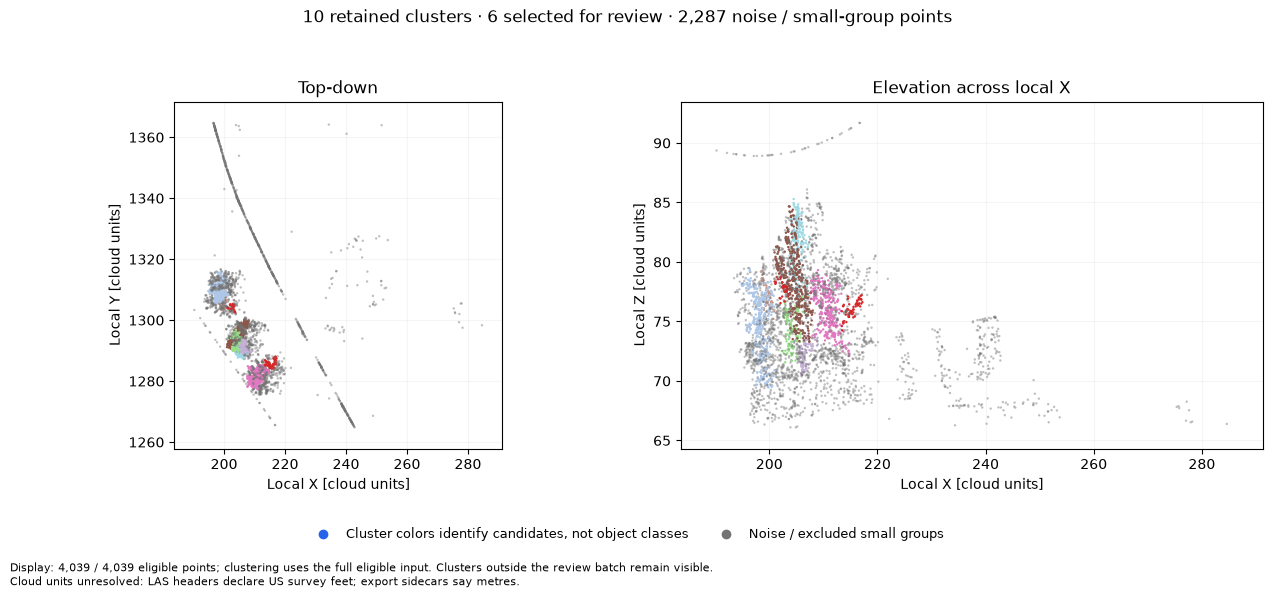

In [4]:
NEIGHBORHOOD_DISTANCE = 0.8
MIN_CLUSTER_POINTS = 40
MIN_NEIGHBORS = 5
MAX_CANDIDATES = 6
batch = objects.extract_candidates(source, NEIGHBORHOOD_DISTANCE, MIN_CLUSTER_POINTS,
                                   min_samples=MIN_NEIGHBORS, max_candidates=MAX_CANDIDATES)
print("Candidate cache hit:", batch["cache_hit"], "| Cache:", batch["cache_dir"])
print("Original extraction runtime (s):", batch["manifest"]["runtime_seconds"])
show_table([batch["manifest"]["counts"]])
show_table([row for row in batch["cluster_table"] if row["status"] != "below_min_cluster_points"])
if len(batch["eligible_indices"]):
    views.show_clusters(source, batch)
else:
    print("No CSF non-ground points here. Select a populated region in section 1.")

Noise, small rejected groups, and candidates beyond the review batch remain visible or recorded. `membership.npz` preserves full group membership, including rejected groups. Region indices address original cached records, and sample-row indices address the hashed development LAS file. XYZ and original 16-bit RGB are preserved.

A cluster may be a fragment, multiple objects, vegetation, or residual ground. A boundary warning means it is near the selected region edge; no warning does **not** prove completeness. Poor groups should be recorded honestly and investigated with the controls above.

## 4. Select and view a candidate

**Navigation:** edit `CANDIDATE_INDEX` below to `0`, `1`, `2`, and so on. Rerun this cell and the display/render/prediction cells to move next or previous; extraction need not rerun. Check the printed candidate ID before reviewing.

Static panels show original RGB in top/front/side views and a wider original-sample context. Candidate points are larger; a box marks their extent. Context can include ground and unrelated objects. Coordinates are translated by a shared origin only, with no unit conversion.

In [5]:
CANDIDATE_INDEX = 0  # EDIT to advance or go back.
candidate, render_record, prediction, inference_error = None, None, None, None
if not batch["candidates"]:
    raise ValueError("No retained candidates. Inspect noise and adjust the region/clustering.")
if not 0 <= CANDIDATE_INDEX < len(batch["candidates"]):
    raise IndexError(f"Choose 0 through {len(batch['candidates'])-1}.")
candidate = batch["candidates"][CANDIDATE_INDEX]
render_record, prediction, inference_error = None, None, None
print(f"Candidate {CANDIDATE_INDEX} of 0..{len(batch['candidates'])-1}: {candidate['id']}")
print("Points:", candidate["point_count"], "| Near boundary:", candidate["touches_region_boundary"])
existing_review = objects.load_review(batch, candidate)
show_table([existing_review["human_review"]] if existing_review else [{"status": "Not yet reviewed"}])

Candidate 0 of 0..5: 5387f413fa4c74f0_00030
Points: 447 | Near boundary: False


status
Not yet reviewed


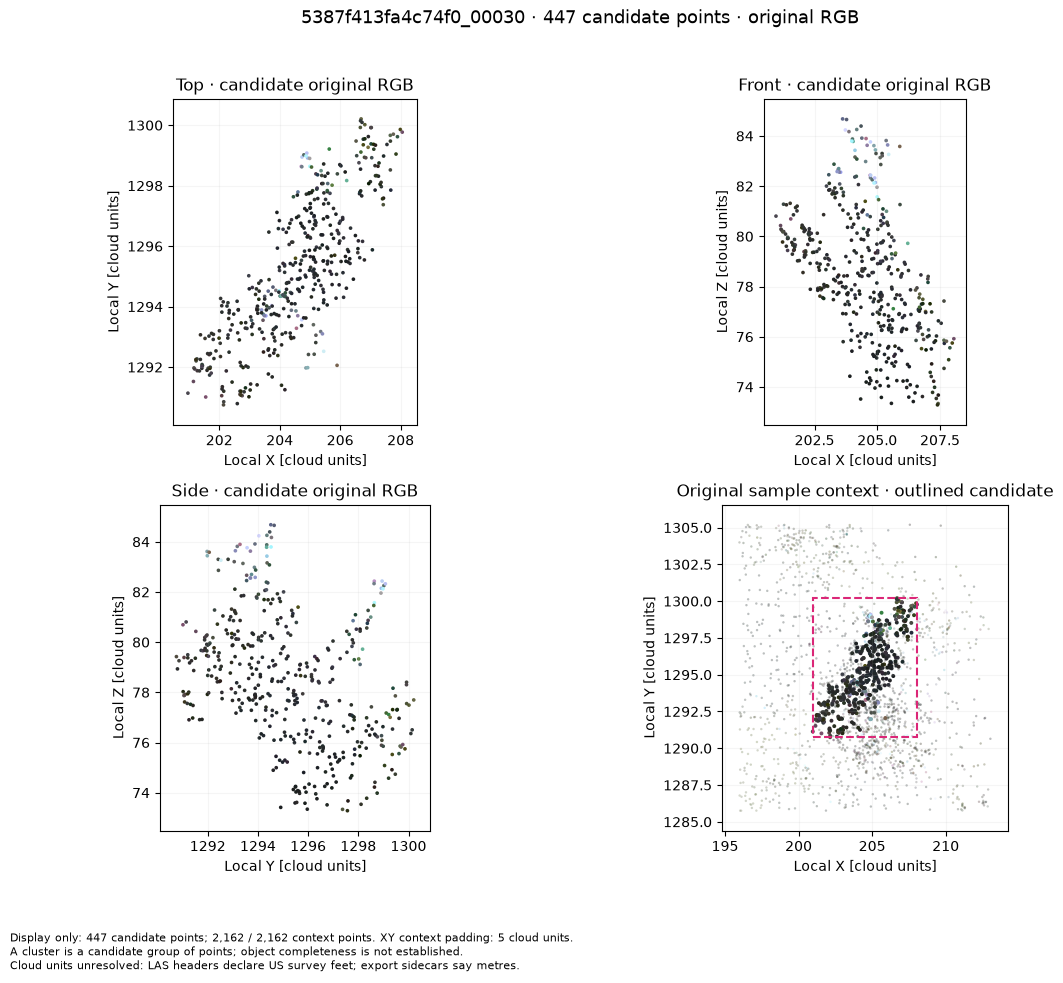

In [6]:
DISPLAY_CONTEXT_PADDING = 5.0
views.show_candidate(source, candidate, context_padding=DISPLAY_CONTEXT_PADDING)

### Interactive 3D ? browser fallback

The next cell exports a **self-contained local HTML file** with Plotly embedded. It avoids VS Code's missing-renderer error; notebook trust alone cannot repair that error. Open the printed file in your browser (Explorer: double-click the HTML file), drag to rotate, and toggle context in the legend. Static panels above still work. No point data are uploaded.

In [2]:
from new_candidate_comparison import export_interactive
interactive = views.candidate_3d(source, candidate, context_padding=DISPLAY_CONTEXT_PADDING)
if interactive is not None:
    browser_view = export_interactive(interactive, PROJECT_DIR / "outputs/objects/interactive" / f"{candidate['id']}.html")

Interactive HTML: C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\objects\interactive\5387f413fa4c74f0_00030.html
Open this file in your browser (Explorer: double-click the HTML file).


C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\objects\interactive\5387f413fa4c74f0_00030.html

## 5. Render clean model inputs

These four images contain only candidate RGB points from front, side, top, and oblique angles. They contain **no axes, text, boxes, filenames, reviewed labels, or context**. Notebook captions are outside the saved PNGs and are not passed to CLIP. Human-facing inspection figures are never model inputs.

Orthographic projection, depth ordering, and small pixel splats make the points visible. Original RGB is quantized to 8 bits; no surfaces or textures are invented. These are point renders, not photographs. Changing render settings or candidate content changes the cache; changing a human review does not.

Render cache hit: True | Manifest: C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\objects\renders\74b4f0b799bb72754c6f7364abba0b010a4d89d7369d1a49ae2c96150f54941c\manifest.json


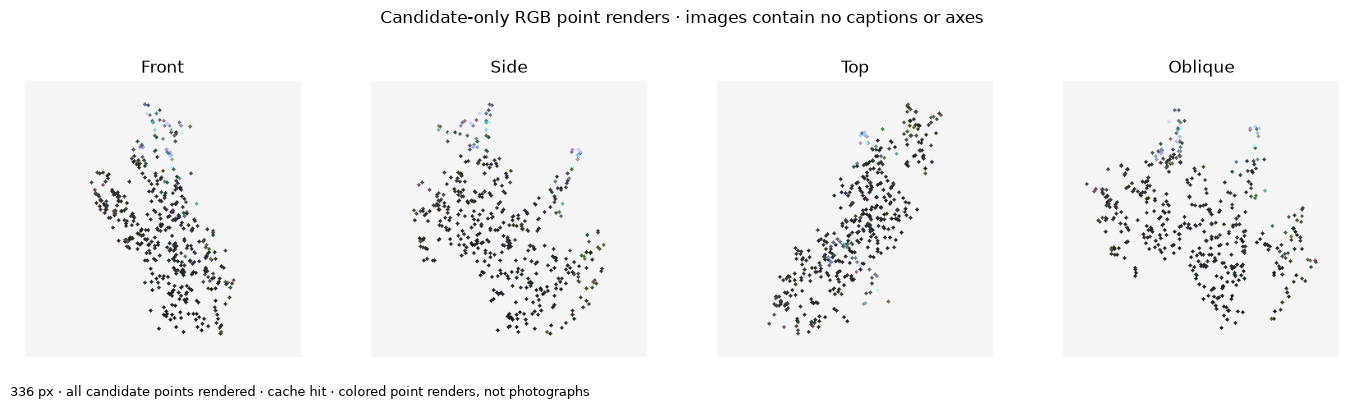

In [8]:
RENDER_SETTINGS = dict(image_size=336, point_radius=2, padding_fraction=0.08,
                       background_rgb=[245, 245, 245])
render_record, prediction = None, None
render_record = views.render_candidate(source, candidate, RENDER_SETTINGS)
print("Render cache hit:", render_record["cache_hit"], "| Manifest:", render_record["manifest_path"])
views.show_renders(render_record)

## 6. Score editable descriptions with pretrained CLIP

We use **`openai/clip-vit-base-patch32`** with the official processor and a locally pinned model revision. Setup follows the [official model card](https://huggingface.co/openai/clip-vit-base-patch32) and [Transformers CLIP documentation](https://huggingface.co/docs/transformers/model_doc/clip). The first load downloads approximately 600 MB of public weights; subsequent runs use local files.

CLIP compares normalized image and text embeddings. We show per-view cosine similarities and rank descriptions by their mean across views. **These are not calibrated probabilities.** Sparse or incomplete renders differ from typical training imagery, so a leading match can be wrong. Descriptions constrain what CLIP can suggest; there is no reliable automatic unknown-class decision here.

View disagreement is the fraction of views whose first choice differs from the aggregate first choice. It exposes instability, not accuracy. Editing descriptions changes inference but reuses candidates and renders.

In [9]:
CHECKPOINT = "openai/clip-vit-base-patch32"
DEVICE = "cpu"
CLASS_DESCRIPTIONS = [
    "a passenger car", "a truck or van", "a tree with a trunk and branches",
    "a bush or shrub", "a utility pole", "a streetlight", "a traffic sign",
    "a fence or railing", "a building wall", "a road or ground surface",
    "a bicycle", "a pile of debris",
]
RUN_INFERENCE = True  # Local model; cached scores do not reload model weights.

In [10]:
prediction, inference_error = None, None
if RUN_INFERENCE:
    try:
        if render_record is None:
            raise ValueError("Run the clean-render cell for this candidate first.")
        prediction = clip.score_candidate(PROJECT_DIR, candidate, render_record,
                                           CLASS_DESCRIPTIONS, checkpoint=CHECKPOINT, device=DEVICE)
        clip.show_predictions(prediction)
    except Exception as error:
        inference_error = f"{type(error).__name__}: {error}"
        print("Inference did not succeed:", inference_error)
        print("Candidate inspection/review remain available; no predictions were invented.")
else:
    print("Inference disabled. No prediction is assigned.")

candidate,checkpoint,resolved_commit,cache_hit,aggregate_top1,view_top1_disagreement_fraction,score_meaning
5387f413fa4c74f0_00030,openai/clip-vit-base-patch32,3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268,True,a pile of debris,0,Cosine similarity; not a calibrated probability


rank,class_description,cosine_similarity
1,a pile of debris,0.2273
2,a bush or shrub,0.2103
3,a road or ground surface,0.2093
4,a bicycle,0.2082
5,a truck or van,0.2063


view,top1,agrees_with_aggregate,top3
Front,a pile of debris,True,"[ { ""rank"": 1, ""class_description"": ""a pile of debris"", ""cosine_similarity"": 0.2318…[ { ""rank"": 1, ""class_description"": ""a pile of debris"", ""cosine_similarity"": 0.2318342626094818 }, { ""rank"": 2, ""class_description"": ""a road or ground surface"", ""cosine_similarity"": 0.2112129032611847 }, { ""rank"": 3, ""class_description"": ""a truck or van"", ""cosine_similarity"": 0.20813298225402832 } ]"
Side,a pile of debris,True,"[ { ""rank"": 1, ""class_description"": ""a pile of debris"", ""cosine_similarity"": 0.2169…[ { ""rank"": 1, ""class_description"": ""a pile of debris"", ""cosine_similarity"": 0.21696434915065765 }, { ""rank"": 2, ""class_description"": ""a bush or shrub"", ""cosine_similarity"": 0.2102225124835968 }, { ""rank"": 3, ""class_description"": ""a bicycle"", ""cosine_similarity"": 0.20895513892173767 } ]"
Top,a pile of debris,True,"[ { ""rank"": 1, ""class_description"": ""a pile of debris"", ""cosine_similarity"": 0.2294…[ { ""rank"": 1, ""class_description"": ""a pile of debris"", ""cosine_similarity"": 0.22945988178253174 }, { ""rank"": 2, ""class_description"": ""a road or ground surface"", ""cosine_similarity"": 0.21658799052238464 }, { ""rank"": 3, ""class_description"": ""a bicycle"", ""cosine_similarity"": 0.21562117338180542 } ]"
Oblique,a pile of debris,True,"[ { ""rank"": 1, ""class_description"": ""a pile of debris"", ""cosine_similarity"": 0.2310…[ { ""rank"": 1, ""class_description"": ""a pile of debris"", ""cosine_similarity"": 0.231043741106987 }, { ""rank"": 2, ""class_description"": ""a bush or shrub"", ""cosine_similarity"": 0.21873924136161804 }, { ""rank"": 3, ""class_description"": ""a building wall"", ""cosine_similarity"": 0.20872697234153748 } ]"


### Cache this small batch

This optional cell renders and scores at most `MAX_CANDIDATES` candidates for faster navigation. It does not review them, assign human labels, or expand to the entire cloud. Errors remain explicit.

In [11]:
PRECOMPUTE_BATCH = True
batch_scores = []
if PRECOMPUTE_BATCH and RUN_INFERENCE:
    for item in batch["candidates"]:
        try:
            images = views.render_candidate(source, item, RENDER_SETTINGS)
            result = clip.score_candidate(PROJECT_DIR, item, images, CLASS_DESCRIPTIONS,
                                           checkpoint=CHECKPOINT, device=DEVICE)
            batch_scores.append(dict(candidate_index=item["candidate_index"], candidate_id=item["id"],
                top_prediction=result["top1"], cosine=result["top1_cosine"],
                view_disagreement=result["top1_disagreement_fraction"], cache_hit=result["cache_hit"]))
        except Exception as error:
            batch_scores.append(dict(candidate_id=item["id"], error=f"{type(error).__name__}: {error}"))
show_table(batch_scores)

candidate_index,candidate_id,top_prediction,cosine,view_disagreement,cache_hit
0,5387f413fa4c74f0_00030,a pile of debris,0.2273,0,True
1,5387f413fa4c74f0_00081,a bush or shrub,0.2306,0,True
2,5387f413fa4c74f0_00012,a pile of debris,0.2348,0,True
3,5387f413fa4c74f0_00045,a pile of debris,0.2307,0,True
4,5387f413fa4c74f0_00019,a pile of debris,0.224,0.25,True
5,5387f413fa4c74f0_00049,a pile of debris,0.2334,0.25,True


## 7. Confirm or correct, and record crop quality — paused

Record **class** separately from **crop quality**:

- `DECISION = "accept"`: explicitly accept the current aggregate description.
- `DECISION = "correct"`: enter your class in `CORRECTED_LABEL`, even if absent from the model descriptions.
- `DECISION = "unlabeled"`: save crop-quality notes without asserting a class.

Choose `CROP_QUALITY`: **complete object**, **incomplete object**, **multiple objects**, **ground contamination**, or **unclear**. These are your observations, not model output.

Copy the printed candidate ID into `REVIEW_FOR_CANDIDATE_ID`, edit your decision and crop quality, and run the controls cell. Then set `SAVE_REVIEW = True` in the save cell and run it. Saving writes immediately with timestamp and revision history. Set that switch back to `False` afterward. Explicit ID confirmation prevents old review text being applied to another candidate during a later Run All. Reviews reload after a kernel restart without needing inference.

**Pause for this pass:** `HUMAN_REVIEW_PAUSED = True` blocks saving even if the save switch is enabled. Existing review records still load. Do not label the new dense components yet; inspect the quality comparisons below.

In [12]:
REVIEW_FOR_CANDIDATE_ID = ""  # PASTE the displayed candidate ID after inspecting it.
DECISION = "unlabeled"       # "accept", "correct", or "unlabeled".
CORRECTED_LABEL = ""         # Required only for "correct".
CROP_QUALITY = "unclear"     # Choose from the five options above.
NOTES = ""
print("Selected candidate ID to confirm:", candidate["id"])
print("Review confirmation:", REVIEW_FOR_CANDIDATE_ID or "Not confirmed; saving is disabled")
print("Model suggestion:", prediction["top1"] if prediction else "No successful inference")

Selected candidate ID to confirm: 5387f413fa4c74f0_00030
Review confirmation: Not confirmed; saving is disabled
Model suggestion: a pile of debris


In [13]:
SAVE_REVIEW = False  # EDIT to True, then run this cell to save immediately.
if HUMAN_REVIEW_PAUSED:
    print("Manual review saving is paused. Existing reviews remain unchanged.")
elif SAVE_REVIEW:
    if candidate is None or REVIEW_FOR_CANDIDATE_ID != candidate["id"]:
        raise ValueError("Inspect the selected candidate, copy its ID into the review controls, and rerun them.")
    if candidate["source_identity"] != source["identity"] or candidate["batch_cache_key"] != batch["cache_key"]:
        raise ValueError("Source or batch changed. Reselect the candidate and review it.")
    if prediction and (prediction["candidate_id"] != candidate["id"] or
            prediction["prompts"] != CLASS_DESCRIPTIONS or prediction["checkpoint"] != CHECKPOINT or
            prediction["cache_provenance"]["device"] != DEVICE or
            render_record is None or prediction["render_key"] != render_record["cache_key"]):
        raise ValueError("Prediction settings changed. Rerun clean renders and inference before saving.")
    if DECISION == "accept" and prediction is None:
        raise ValueError("No prediction to accept; use correct or unlabeled.")
    label = prediction["top1"] if DECISION == "accept" else CORRECTED_LABEL if DECISION == "correct" else None
    evidence = prediction or dict(candidate_id=candidate["id"], status="unavailable",
                                  error=inference_error or "Inference disabled/not run",
                                  checkpoint=CHECKPOINT, prompts=CLASS_DESCRIPTIONS)
    saved_review = objects.save_review(batch, candidate, evidence, label, CROP_QUALITY, NOTES, DECISION)
    SAVE_REVIEW = False
    show_table([saved_review["human_review"]])
    print("Saved revision", saved_review["revision"], "at", saved_review["saved_utc"])
else:
    print("Review not saved. No human label was assigned by this cell.")

Manual review saving is paused. Existing reviews remain unchanged.


In [14]:
reloaded = objects.load_review(batch, candidate)
show_table([reloaded["human_review"]] if reloaded else [{"status": "Selected candidate remains unreviewed"}])
show_table(objects.review_table(batch))

status
Selected candidate remains unreviewed


candidate_index,candidate_id,points,reviewed,reviewed_label,crop_quality,notes
0,5387f413fa4c74f0_00030,447,False,—,—,
1,5387f413fa4c74f0_00081,394,False,—,—,
2,5387f413fa4c74f0_00012,308,False,—,—,
3,5387f413fa4c74f0_00045,140,False,—,—,
4,5387f413fa4c74f0_00019,139,False,—,—,
5,5387f413fa4c74f0_00049,89,False,—,—,


## 8. Advance, restart, and understand the caches

**Next / Previous:** edit `CANDIDATE_INDEX` in section 4, then rerun selection, display, clean-render, and prediction cells. Cached artifacts are reused. Run the review-controls cell for that candidate, make your decision, and save. Source loading and clustering do not need to rerun just to review another item.

After a restart, run from the top with the same settings. Source fingerprints are rechecked, matching caches are reused, and reviews reload. Predictions never overwrite human labels; human corrections do not retrain CLIP.

| Change | What happens |
|---|---|
| Reviewed label, crop quality, note | Only a review revision is saved; no extraction, rendering, or inference. |
| Candidate index | Cached candidate artifacts load; missing ones are computed. |
| Descriptions or checkpoint | Candidates/renders remain; relevant inference cache changes. Model revision is pinned locally. |
| Render settings or renderer | Candidates remain; renders and inference change. |
| Source, CSF result, region, clustering settings | Relevant source/extraction identity changes; old artifacts and reviews stay with their original membership. |

Membership includes source-cache records and original-sample row numbers. Inference records contain checkpoint/commit, prompts, image hashes, per-view scores, aggregation, versions, and runtime. Review records retain a separate prediction snapshot alongside source/region, clustering settings, reviewed label, crop quality, and notes. Previous revisions remain available.

If clusters or predictions look poor, inspect noise/context and record that limitation. This prototype intentionally leaves geometry features, retraining, and broader data processing for later.

<a id="candidate-quality-comparison"></a>
## Candidate quality comparison

**Completed bounded pass: 10 existing candidates inspected, 3 dense regions extracted, one grouping attempt per region. Manual labeling remains paused.**

**Start with candidate `00012` below.** It has the best retained seed coverage and no crop-edge contact. These cells load saved figures and real model results only: no raw scan, clustering, inference, or review write occurs here. They can be run directly after selecting the existing **LiDAR Object Review (.venv-ground)** kernel.

### What caused the sparse appearance?

The development LAS uses deterministic spatial-hash sampling with a 1.7723% selection probability. It is not the voxel preview. The existing renderer uses every candidate point at 336 pixels with a 2 pixel radius; it does not subsample model inputs. The old candidates contained only40–447points. Nearby retained clusters can be only0.45–0.52source units apart, so fragmented surfaces contribute too.

For the three selected original XYZ bounding boxes, raw extraction recovered **52.9–58.3 times as many points as the sample in the same boxes**. This controls for crop size. Dense-candidate counts also reflect changed grouping and must not be interpreted as pure density gains.

### How this pass stayed bounded

Selection used count, shape, location, and distance from the original region boundary, with no CLIP score in the selection rule. `00081` is populated and tall; `00012` spans two principal directions; `00019` is narrower and more vertical. All original seeds were interior. Ten cached groups were inspected; the three were chosen to avoid three nearly identical fragments.

One chunked pass through **Run 1 Laser Left.las** collected all three crops, using original XY bounds plus a 5 source-unit margin. The full shared sample Z interval was kept so local ground remained available. All raw attributes, RGB, XYZ, and raw row numbers are cached. Every original seed record was recovered exactly. Crops contain multiple structures and ground; raw points did not inherit sparse candidate membership.

New points received **one local CSF pass with the existing saved parameters**: cloth resolution 1.0, threshold 0.8, rigidness 3, time step 0.65, 500 iterations, slope smoothing on. Its local terrain context differs from the previous whole-sample CSF run. No ground-filter parameters were tuned.

One DBSCAN grouping used real representative points from occupied voxels. Voxel size was twice measured median raw spacing, clipped to0.06–0.18source units; neighborhood distance was three voxel widths, with 3 neighbors. The component supported by the most original seeds was selected. Every real point in its member voxels was restored. All other components, noise, and ground remain in the crop/membership cache. This creates a denser **candidate**, not a verified complete object.

### Saved results

Each comparison uses front, side, top, and oblique views with the **same origin, camera, framing, scale, resolution, and point radius within each row**. Original RGB is preserved apart from 8 bit PNG quantization. No surfaces were generated or holes filled. Figure captions never enter CLIP. Context scores remain separate from candidate-only scores.

The sparse CLIP scores below use the new shared frame so density comparisons have matching framing. They can differ from old candidate-autofit scores; those prior results are preserved. CLIP similarities and viewpoint agreement do not establish accuracy or object completeness.

In [15]:
from pathlib import Path
import object_quality as quality
import object_quality_report as quality_display
QUALITY_RUN = Path.cwd() / 'outputs/objects/quality/20260911T074133_107528Z'
quality_pass = quality.load_report(QUALITY_RUN)  # Saved artifacts only.
quality_display.show_summary(quality_pass)

candidate,sparse_points,dense_points,same_box_density_gain,original_seeds_retained,dense_crop_edge,CLIP_suggestion_unverified,view_disagreement
00081,394,"20,163",52.9,242/394,False,a bush or shrub,0.5
00012,308,"32,146",54,298/308,False,a bush or shrub,0.25
00019,139,"31,325",58.3,86/139,True,a bush or shrub,0


### Inspect first: `00012` — the clearest retained structure

The dense proposal contains **32,146 points**, retains **298/308 original seeds**, and does not touch the crop boundary. Its silhouette is much more coherent and looks vegetation-like, but a complete isolated object is not established. CLIP's dense candidate suggestion is “a bush or shrub” at mean cosine 0.268, with 25% view disagreement. Its wider context instead leads with a tree description; these are separate unverified model suggestions.

[Open full-size comparison](outputs/objects/quality/20260911T074133_107528Z/comparison_00012.png).

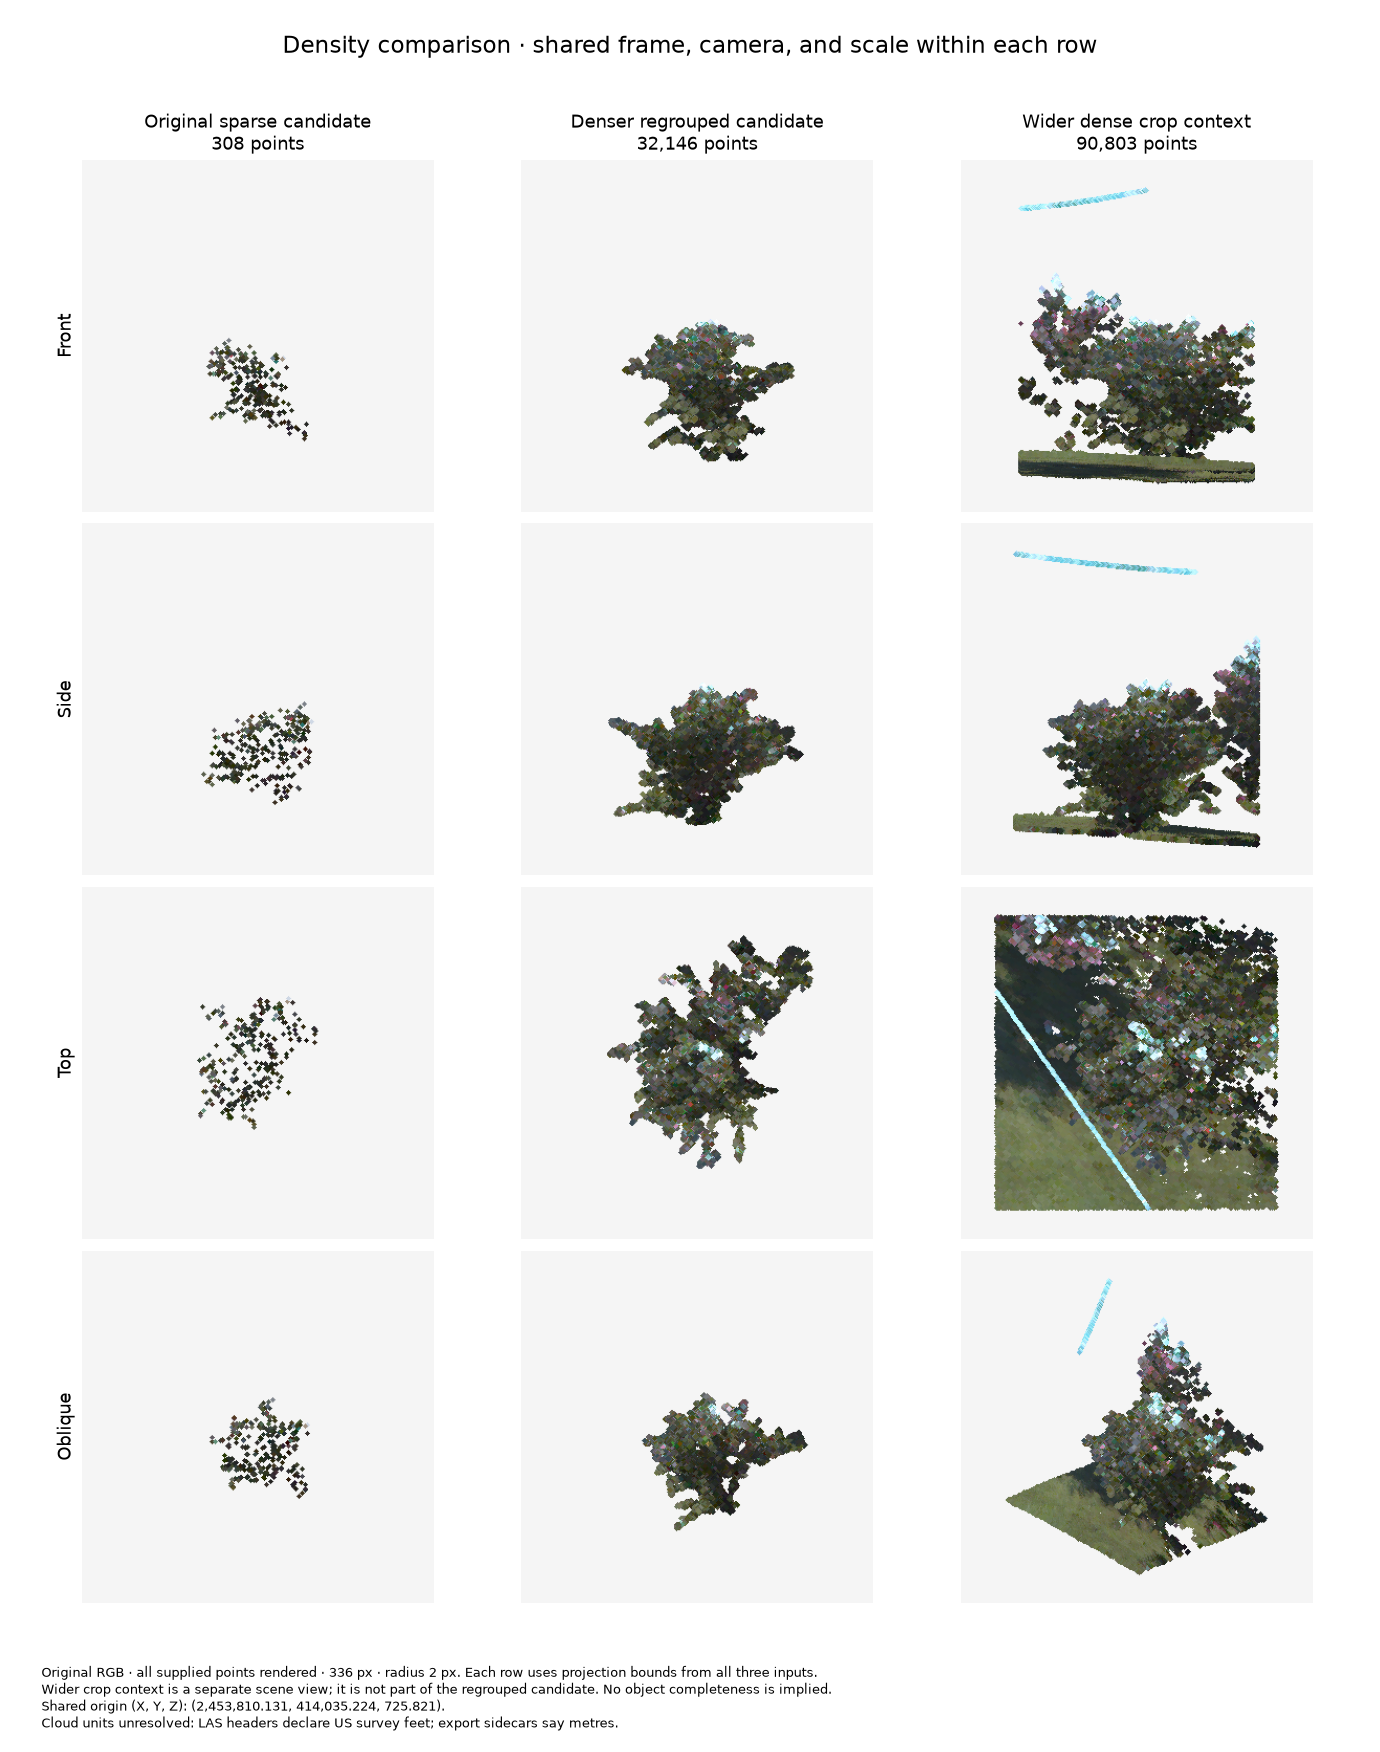

5387f413fa4c74f0_00012 | 308 points; broad structure spread across two directions; interior and distinct from the narrow vertical seed.
Raw source: Run 1 Laser Left.las | Original sample: run1_left_sample.las


measurement,value
sparse_points,308
dense_candidate_points,"32,146"
wider_raw_context_points,"90,803"
same_xyz_box_sample_points,477
same_xyz_box_raw_points,"25,750"
same_box_density_multiplier,53.9832
original_seed_records_recovered,308
original_seed_exact_selected_count,298
original_seed_local_csf_ground_count,0
dense_touches_crop_boundary,False


**Sparse candidate only.** Cosine similarities, not calibrated probabilities. View disagreement: **25%**.

rank,class_description,cosine_similarity
1,a bush or shrub,0.2503
2,a pile of debris,0.2343
3,a road or ground surface,0.2272
4,a bicycle,0.2227
5,a truck or van,0.2194


view,leading_description,leading_cosine
Front,a bush or shrub,0.2473
Side,a bush or shrub,0.2636
Top,a pile of debris,0.2255
Oblique,a bush or shrub,0.2671


...

rank,class_description,cosine_similarity
1,a bush or shrub,0.2678
2,a pile of debris,0.2602
3,a tree with a trunk and branches,0.2574
4,a bicycle,0.2441
5,a road or ground surface,0.2391


view,leading_description,leading_cosine
Front,a bush or shrub,0.2799
Side,a bush or shrub,0.277
Top,a pile of debris,0.2656
Oblique,a bush or shrub,0.2609


**Wider context only — a region prediction.** Cosine similarities, not calibrated probabilities. View disagreement: **50%**.

rank,class_description,cosine_similarity
1,a tree with a trunk and branches,0.2759
2,a bush or shrub,0.269
3,a pile of debris,0.2598
4,a utility pole,0.2521
5,a road or ground surface,0.2503


view,leading_description,leading_cosine
Front,a tree with a trunk and branches,0.2951
Side,a tree with a trunk and branches,0.2798
Top,a streetlight,0.2714
Oblique,a pile of debris,0.273


In [16]:
quality_display.show_candidate(quality_pass, 1)

### Comparison: `00081` — denser, still partial

The selected component contains **20,163 points** and retains **242/394 original seeds**. Seven original seeds change to ground under local CSF; most remaining omissions are other density components. This is a useful warning that higher density alone does not ensure complete grouping. The component stays inside the crop, but the wider context reveals substantial structure outside it. Dense CLIP view disagreement is 50%.

[Open full-size comparison](outputs/objects/quality/20260911T074133_107528Z/comparison_00081.png).

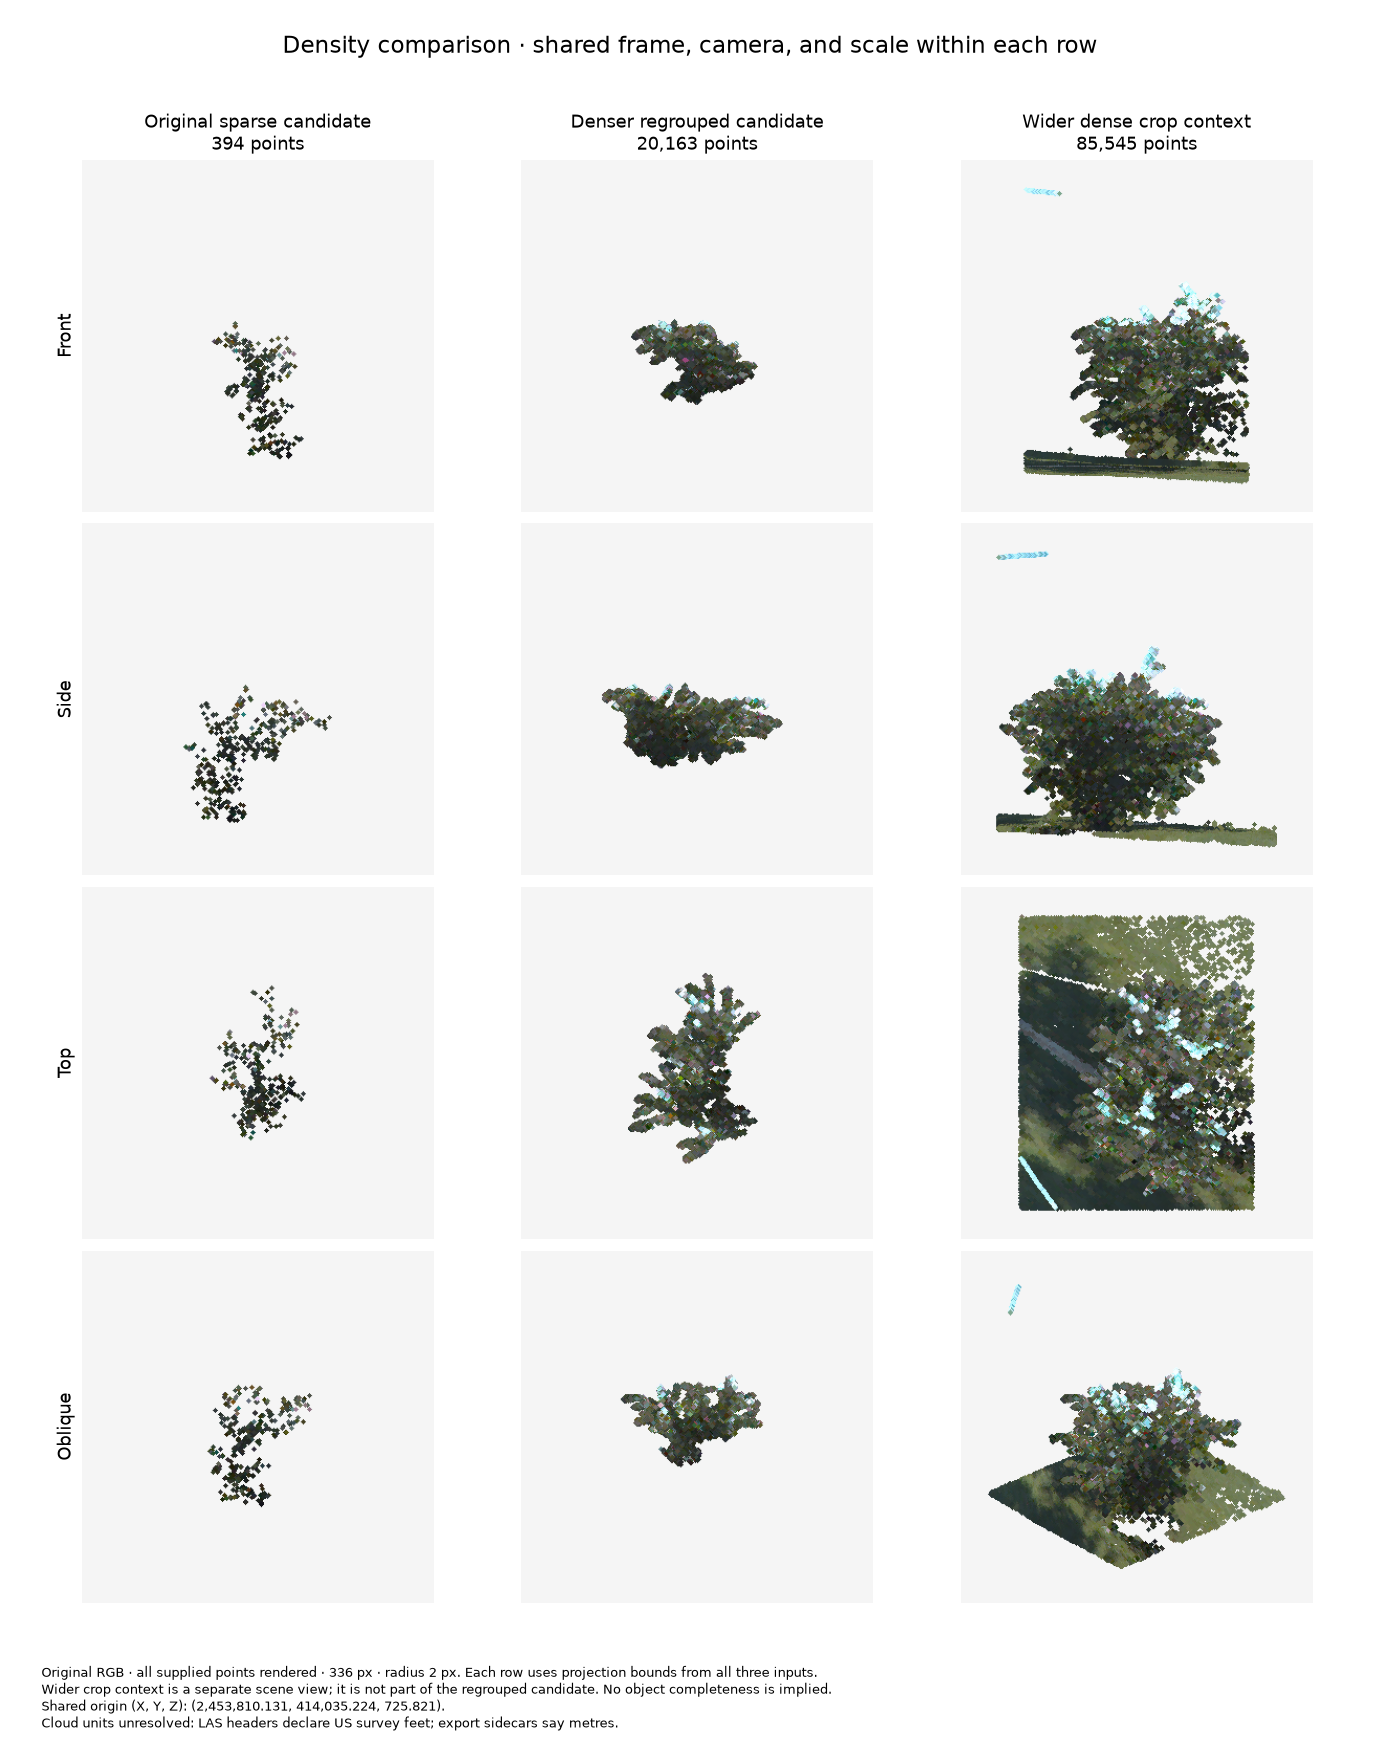

5387f413fa4c74f0_00081 | 394 points; populated tall structure; interior, with a different position and shape from the other choices.
Raw source: Run 1 Laser Left.las | Original sample: run1_left_sample.las


measurement,value
sparse_points,394
dense_candidate_points,"20,163"
wider_raw_context_points,"85,545"
same_xyz_box_sample_points,701
same_xyz_box_raw_points,"37,106"
same_box_density_multiplier,52.933
original_seed_records_recovered,394
original_seed_exact_selected_count,242
original_seed_local_csf_ground_count,7
dense_touches_crop_boundary,False


**Sparse candidate only.** Cosine similarities, not calibrated probabilities. View disagreement: **0%**.

rank,class_description,cosine_similarity
1,a bush or shrub,0.2797
2,a tree with a trunk and branches,0.2539
3,a bicycle,0.2433
4,a road or ground surface,0.2315
5,a pile of debris,0.23


view,leading_description,leading_cosine
Front,a bush or shrub,0.2719
Side,a bush or shrub,0.2774
Top,a bush or shrub,0.2859
Oblique,a bush or shrub,0.2837


...

rank,class_description,cosine_similarity
1,a bush or shrub,0.2657
2,a pile of debris,0.25
3,a tree with a trunk and branches,0.249
4,a bicycle,0.2341
5,a road or ground surface,0.2326


view,leading_description,leading_cosine
Front,a tree with a trunk and branches,0.2685
Side,a pile of debris,0.2568
Top,a bush or shrub,0.2799
Oblique,a bush or shrub,0.2704


**Wider context only — a region prediction.** Cosine similarities, not calibrated probabilities. View disagreement: **50%**.

rank,class_description,cosine_similarity
1,a bush or shrub,0.2722
2,a tree with a trunk and branches,0.2631
3,a pile of debris,0.255
4,a road or ground surface,0.2431
5,a utility pole,0.2356


view,leading_description,leading_cosine
Front,a bush or shrub,0.275
Side,a tree with a trunk and branches,0.2728
Top,a road or ground surface,0.2704
Oblique,a bush or shrub,0.2892


In [17]:
quality_display.show_candidate(quality_pass, 0)

### Comparison: `00019` — crop-edge failure remains visible

The 139 point vertical seed grows to **31,325 points**, retaining 86 of 139 original seeds. The new group **touches the crop boundary**, and the side view shows a cut-off structure. Its zero CLIP view disagreement does not make this a good crop. It remains unsuitable for confident object labeling, and this pass deliberately stops without expanding it.

[Open full-size comparison](outputs/objects/quality/20260911T074133_107528Z/comparison_00019.png).

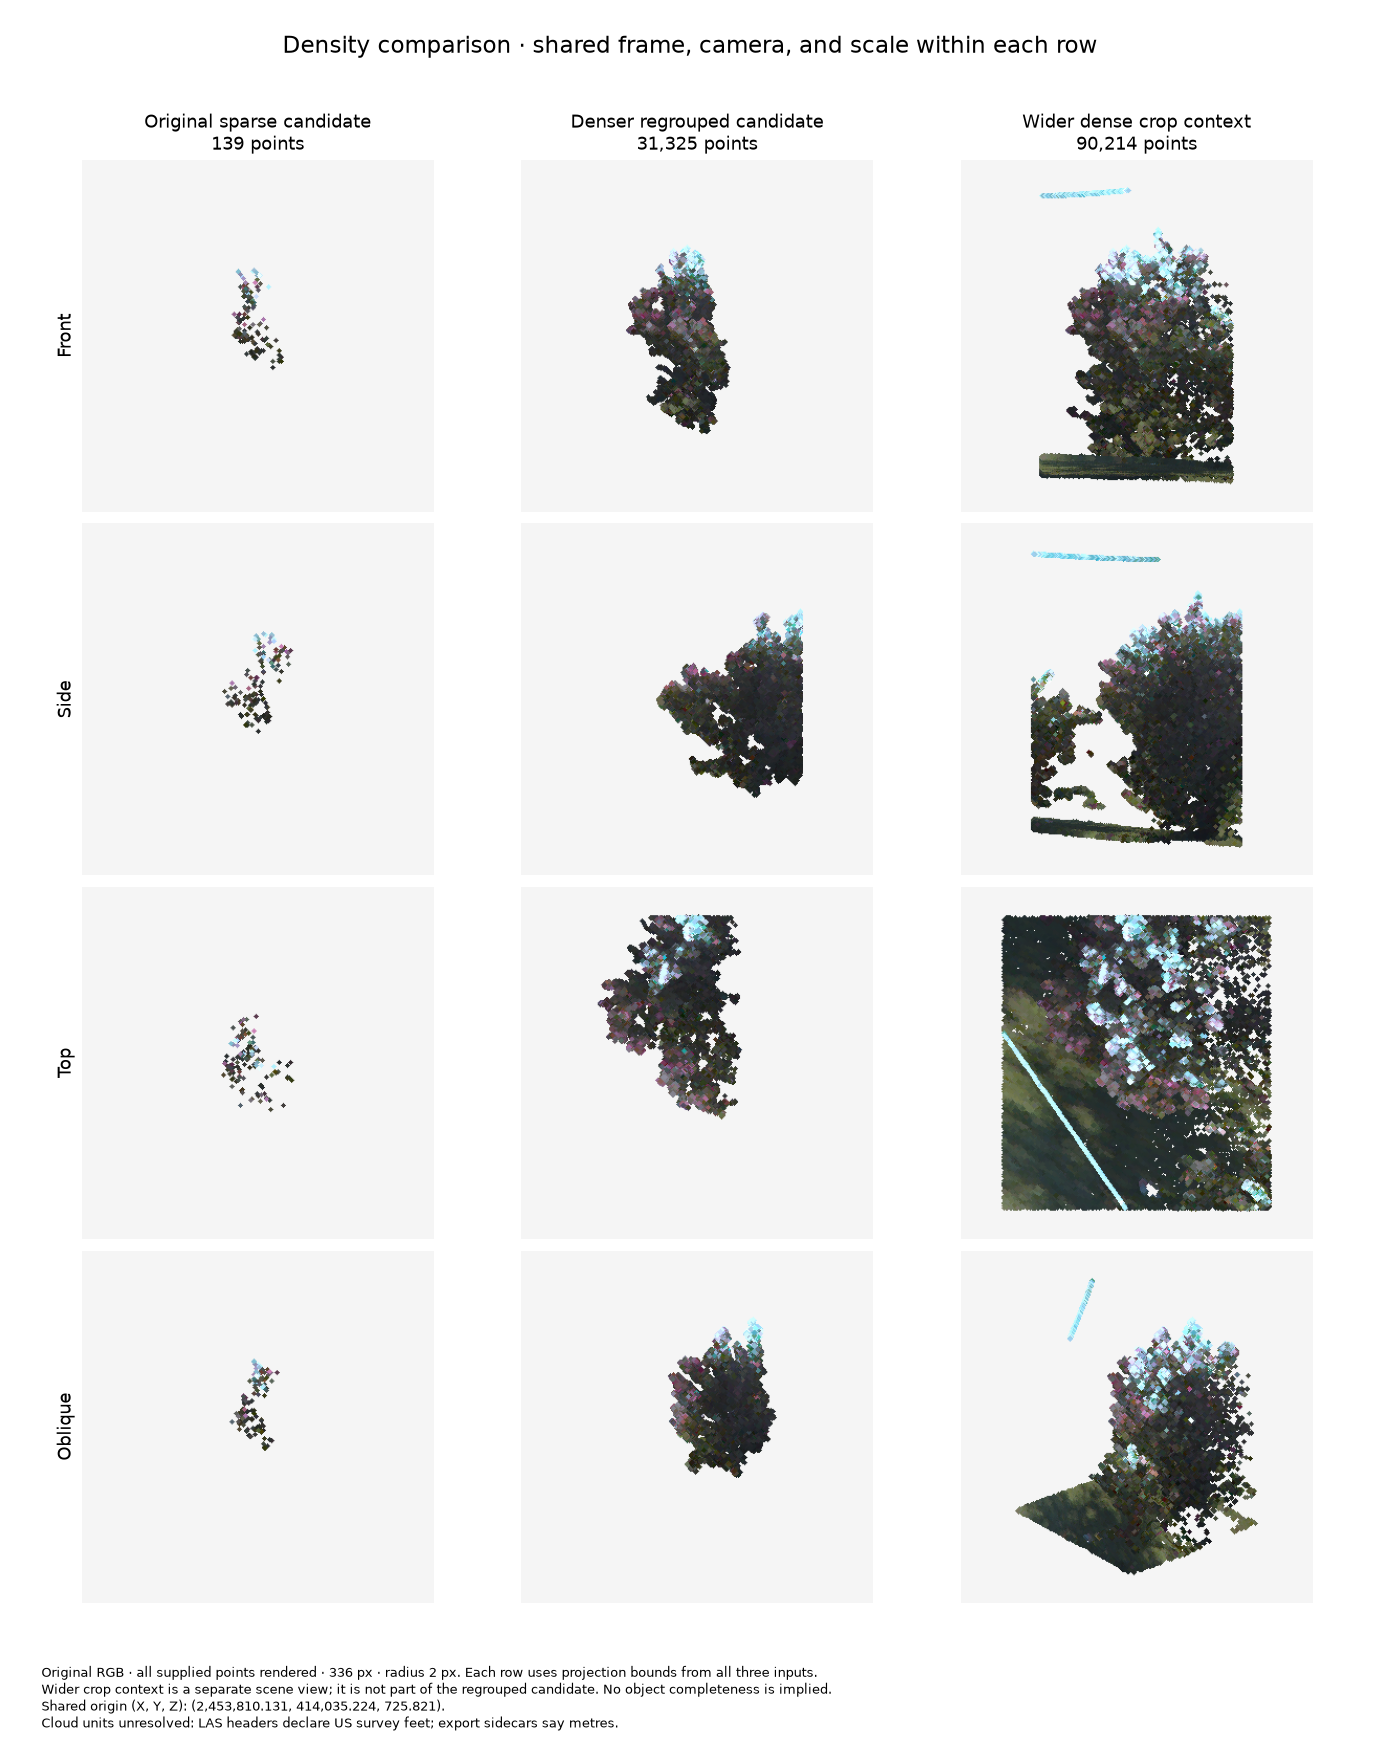

5387f413fa4c74f0_00019 | 139 points; narrower and more vertical than the other choices; interior original seed, with nearby fragments to test.
Raw source: Run 1 Laser Left.las | Original sample: run1_left_sample.las


measurement,value
sparse_points,139
dense_candidate_points,"31,325"
wider_raw_context_points,"90,214"
same_xyz_box_sample_points,168
same_xyz_box_raw_points,"9,794"
same_box_density_multiplier,58.2976
original_seed_records_recovered,139
original_seed_exact_selected_count,86
original_seed_local_csf_ground_count,0
dense_touches_crop_boundary,True


**Sparse candidate only.** Cosine similarities, not calibrated probabilities. View disagreement: **25%**.

rank,class_description,cosine_similarity
1,a bicycle,0.2364
2,a bush or shrub,0.2292
3,a pile of debris,0.2284
4,a road or ground surface,0.2201
5,a truck or van,0.2171


view,leading_description,leading_cosine
Front,a bicycle,0.2414
Side,a bush or shrub,0.238
Top,a bicycle,0.2325
Oblique,a bicycle,0.2388


...

rank,class_description,cosine_similarity
1,a bush or shrub,0.2673
2,a tree with a trunk and branches,0.256
3,a pile of debris,0.2485
4,a bicycle,0.2384
5,a fence or railing,0.2363


view,leading_description,leading_cosine
Front,a bush or shrub,0.2735
Side,a bush or shrub,0.2539
Top,a bush or shrub,0.2621
Oblique,a bush or shrub,0.2797


**Wider context only — a region prediction.** Cosine similarities, not calibrated probabilities. View disagreement: **50%**.

rank,class_description,cosine_similarity
1,a bush or shrub,0.2647
2,a tree with a trunk and branches,0.2608
3,a pile of debris,0.2478
4,a utility pole,0.2408
5,a streetlight,0.2395


view,leading_description,leading_cosine
Front,a bush or shrub,0.2796
Side,a bush or shrub,0.264
Top,a streetlight,0.2591
Oblique,a pile of debris,0.272


In [18]:
quality_display.show_candidate(quality_pass, 2)

### Handoff — stop after this pass

**Diagnosis:** heavy source sampling caused most initial sparsity. The denser views reveal more coherent plant-like structure, but **grouping and complete-object boundaries remain the main limitation**. Rendering already used all input points; the matched comparison keeps those settings fixed. Exact identity remains unverified.

**Single next step:** inspect `00012` against its wider context to decide whether its boundaries are complete enough before resuming manual labeling.

No human labels were saved. Existing ground experiments, sparse candidates, predictions, and reviews remain intact. No whole-scene classification, training, or parameter search was performed.

Artifacts and settings: [20260911T074133_107528Z](outputs/objects/quality/20260911T074133_107528Z/report.json). Implementations: [object_quality.py](object_quality.py), [object_quality_views.py](object_quality_views.py), and [object_quality_report.py](object_quality_report.py). Raw extraction is an explicit helper call with `allow_raw_scan=True`; the notebook quality cells only load the completed pass. A backup of the previous notebook is retained in this run folder.

<a id="new-candidate-comparison"></a>
## New candidate comparison

**Start with `b2a866edbb1fac31_00027` below.** Its narrow vertical seed expands into a much clearer structure with upper crosspieces. All original seed points are retained. Attached structures reach the crop boundary, so the full region is the fallback, **not a verified complete object**. Manual labeling remains paused.

This pass scouted **two 80 × 80 regions** outside the earlier evaluation area: X 2454300–2454380 / Y 414165–414245, and X 2454165–2454245 / Y 414800–414880. Distances remain **source coordinate units**. The cached sample supplied the scout; no third region was searched. A planar and a narrow vertical group were selected using geometry, RGB context and interior boundaries, without CLIP scores. No convincing third compact candidate was selected.

One spacing-informed scout setting was used per region (distance 0.8, 3 neighbors, minimum 25 points). The old dense caches did not cover these locations. **One chunked raw-LAS pass** extracted both original XY boxes plus 8 units of surrounding context, retaining the shared Z interval and exact raw row membership/RGB/coordinates.

Each crop received the existing local CSF settings and **one** spacing-adapted grouping attempt using `object_quality.py`. No retuning loop was run. Both dense groups reach crop edges; the tentative group remains visible for comparison, while the right column shows the **region containing potentially multiple objects**. All unselected points remain cached. The planar group retains 234/234 seeds; the vertical group retains 58/58.

Four shared-frame RGB views and separate candidate/context CLIP results are saved below. The checkpoint **openai/clip-vit-base-patch32** and all 12 class descriptions are unchanged. The tables show the **top three** descriptions and cosine scores, plus viewpoint disagreement. These are suggestions, not probabilities or reviewed labels; no accuracy improvement is claimed.

These cells only read saved artifacts. Keep the existing **LiDAR Object Review (.venv-ground)** kernel; there is no need to rerun the entire notebook.

In [3]:
from pathlib import Path
import object_quality as quality
import new_candidate_comparison as new_comparison
NEW_RUN = Path.cwd() / 'outputs/objects/new_candidates/20260911T140448_622999Z'
new_report = quality.read_json(NEW_RUN / "report.json")
print("Saved scope:", new_report["scope"])

Saved scope: {'scout_regions': 2, 'selected_candidates': 2, 'raw_passes': 1, 'grouping_attempts_per_crop': 1}


### Inspect first: narrow vertical structure `b2a866edbb1fac31_00027`

The dense group has **11,891 points**, within 20,719 context points. It retains all 58 seed points and reveals upper structures absent from the original small fragment. Its connected extensions touch the crop edge: inspect the whole region. Candidate-only CLIP ranks bicycle 0.239, utility pole 0.237, streetlight 0.221, with 50% view disagreement. The region instead leads with utility pole 0.261. Close scores and changed context show why recognition still needs review.

**b2a866edbb1fac31_00027 — vertical elongated**

Grouping is incomplete: use the wider region containing potentially multiple objects as the fallback. The tentative candidate is shown only to explain the grouping result.

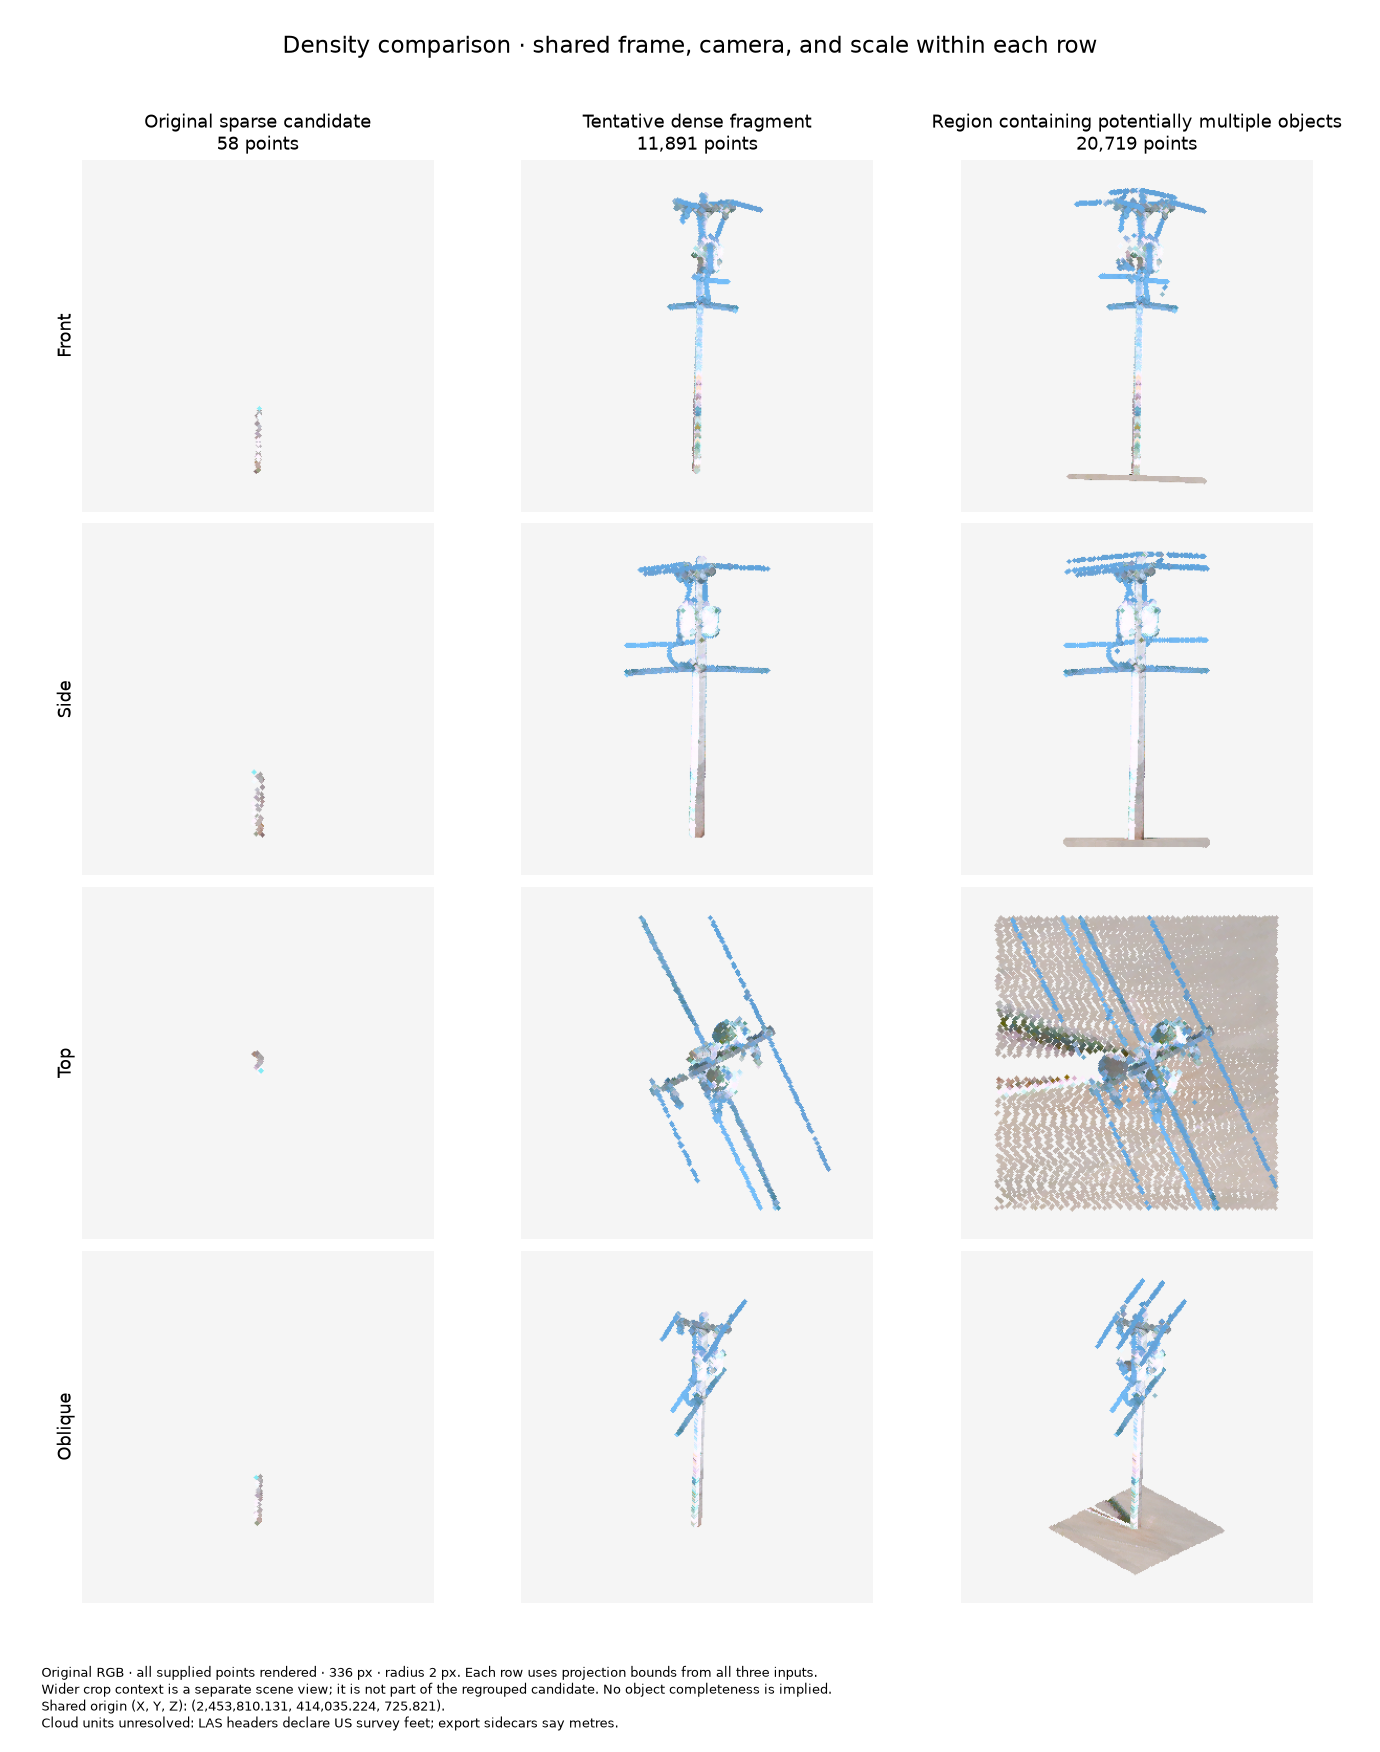

sparse_points,dense_points,context_points,original_seed_retention,crop_boundary
58,"11,891","20,719",58/58,True


**Candidate only (unverified grouping)** — viewpoint disagreement 50%. Cosine similarity, not probability.

rank,class_description,cosine_similarity
1,a bicycle,0.2388
2,a utility pole,0.2369
3,a streetlight,0.2211


view,top_description
Front,a bicycle
Side,a utility pole
Top,a bicycle
Oblique,a utility pole


**Wider region containing potentially multiple objects** — viewpoint disagreement 25%. Cosine similarity, not probability.

rank,class_description,cosine_similarity
1,a utility pole,0.2612
2,a bicycle,0.2489
3,a streetlight,0.2443


view,top_description
Front,a utility pole
Side,a utility pole
Top,a bicycle
Oblique,a utility pole


Browser view: C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\objects\new_candidates\20260911T140448_622999Z\interactive_b2a866edbb1fac31_00027.html


C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\objects\new_candidates\20260911T140448_622999Z\interactive_b2a866edbb1fac31_00027.html

In [4]:
new_comparison.show_saved(new_report, 1)

### Planar structure `1d45ed4734454e12_00041`

The dense group has **21,205 points**, within 42,331 context points, and retains all 234 seed points. The broad thin surface is clearer, but the group includes connected returns and reaches the crop edge. Use the region fallback. Candidate-only CLIP leads with utility pole, while region context leads with building wall; neither is a verified label.

**1d45ed4734454e12_00041 — planar**

Grouping is incomplete: use the wider region containing potentially multiple objects as the fallback. The tentative candidate is shown only to explain the grouping result.

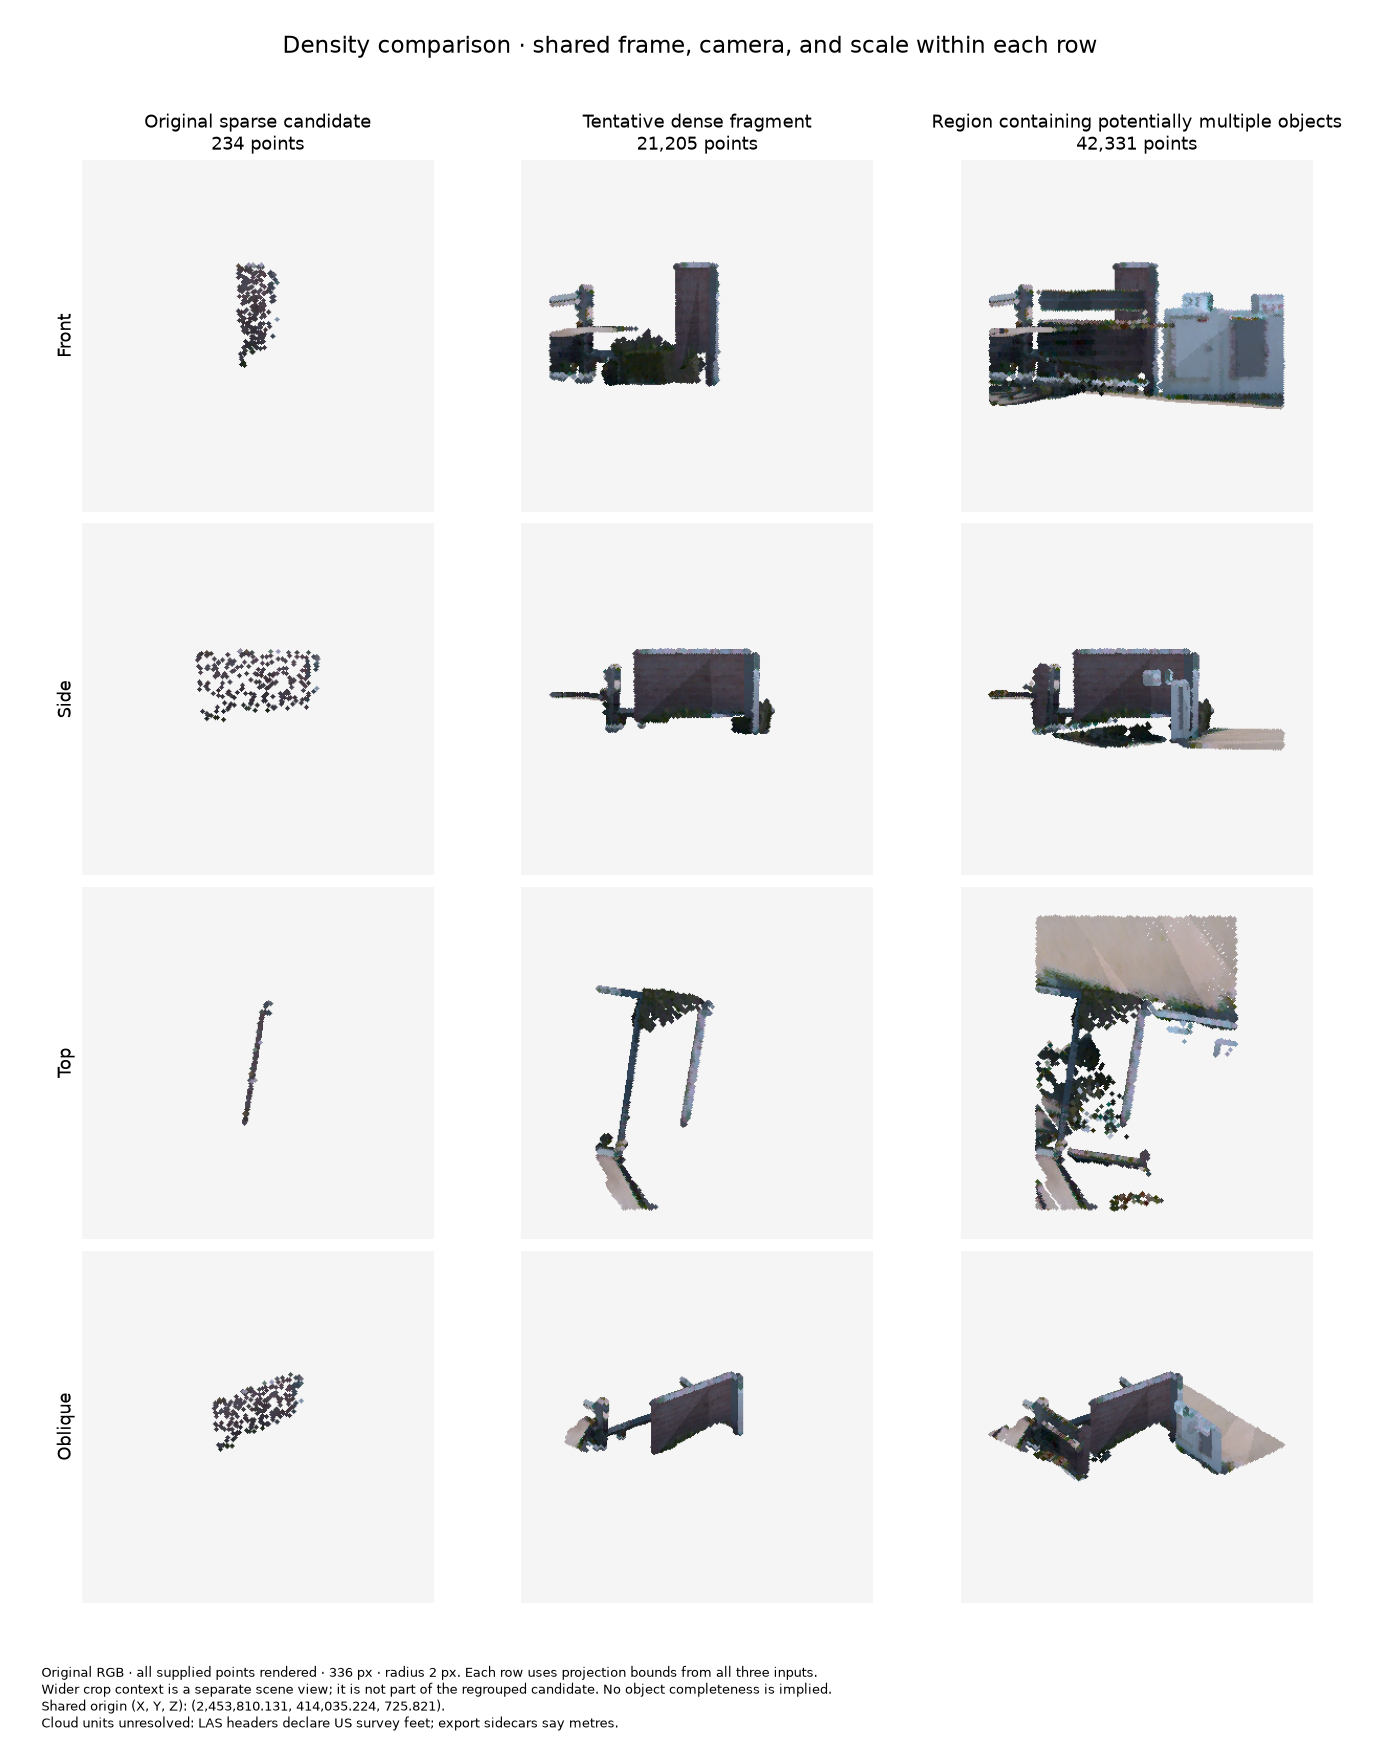

sparse_points,dense_points,context_points,original_seed_retention,crop_boundary
234,"21,205","42,331",234/234,True


**Candidate only (unverified grouping)** — viewpoint disagreement 25%. Cosine similarity, not probability.

rank,class_description,cosine_similarity
1,a utility pole,0.2451
2,a streetlight,0.237
3,a bicycle,0.2319


view,top_description
Front,a utility pole
Side,a road or ground surface
Top,a utility pole
Oblique,a utility pole


**Wider region containing potentially multiple objects** — viewpoint disagreement 50%. Cosine similarity, not probability.

rank,class_description,cosine_similarity
1,a building wall,0.2445
2,a road or ground surface,0.2437
3,a utility pole,0.2419


view,top_description
Front,a building wall
Side,a bicycle
Top,a streetlight
Oblique,a building wall


Browser view: C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\objects\new_candidates\20260911T140448_622999Z\interactive_1d45ed4734454e12_00041.html


C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\objects\new_candidates\20260911T140448_622999Z\interactive_1d45ed4734454e12_00041.html

In [5]:
new_comparison.show_saved(new_report, 0)

### Open the interactive browser view

VS Code's “No renderer could be found” is a frontend renderer problem. The existing interactive cell now exports local HTML instead of depending on that renderer. **Plotly JavaScript is embedded in each HTML file**, so no CDN, notebook trust change, server, or external upload is required. The static figures remain available.

Open the printed HTML file in your browser (Explorer: double-click), or set `OPEN_BROWSER=True` below and run this cell. Drag to rotate; toggle **Tentative dense candidate** and **Wider dense crop context** in the legend. Interactive display is capped at 20,000 points per trace; processing and static render membership are unchanged.

**Remaining issue:** candidate boundaries include attached scene structures, and CLIP still confuses close alternatives. The browser fallback addresses viewing. **Single next step:** inspect the vertical structure in the browser and determine which connected parts belong in one object before resuming labeling. This pass stops here.

In [ ]:
import webbrowser
FIRST_INTERACTIVE = Path(new_report["items"][1]["interactive_html"])
print("Open in your browser:", FIRST_INTERACTIVE)
OPEN_BROWSER = True  # Set True and run this cell to launch the local file.
if OPEN_BROWSER:
    webbrowser.open(FIRST_INTERACTIVE.resolve().as_uri())

Open in your browser: C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\objects\new_candidates\20260911T140448_622999Z\interactive_b2a866edbb1fac31_00027.html
